In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Load the data
df = pd.read_csv(r"C:\Users\Mr.Zabit\Downloads\Ecommerce-Project\data\Ecommerce Customers")
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [4]:
# Basic statistics
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [5]:
df = df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']]

# EDA

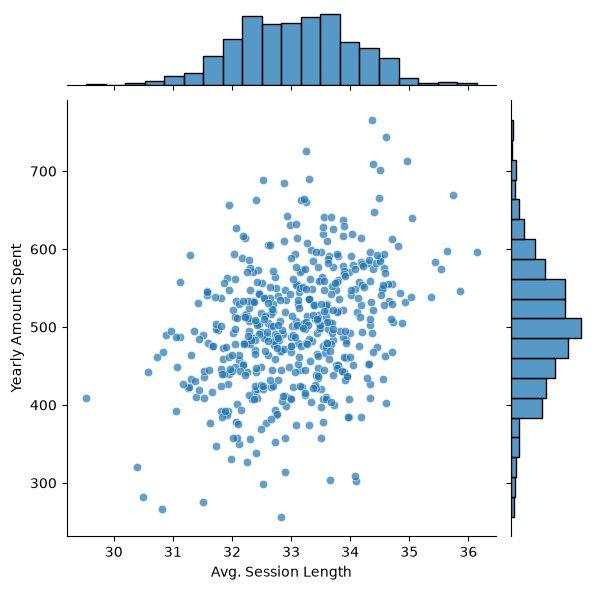

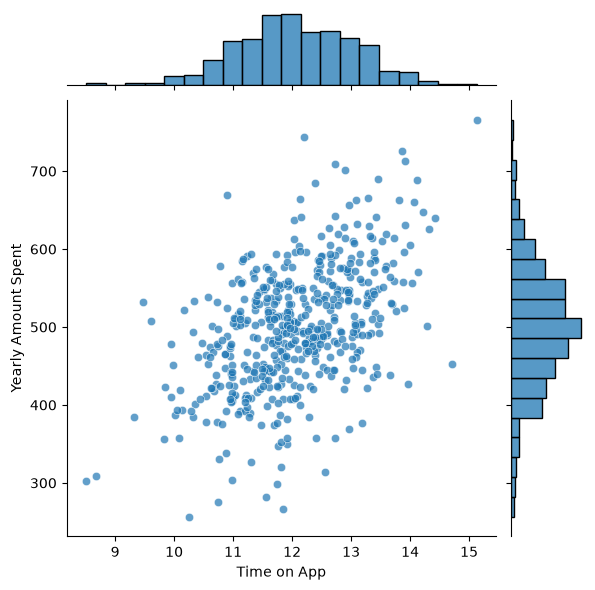

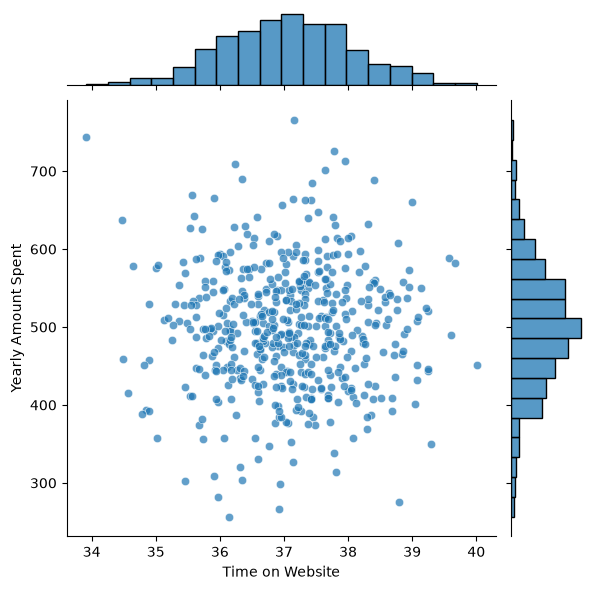

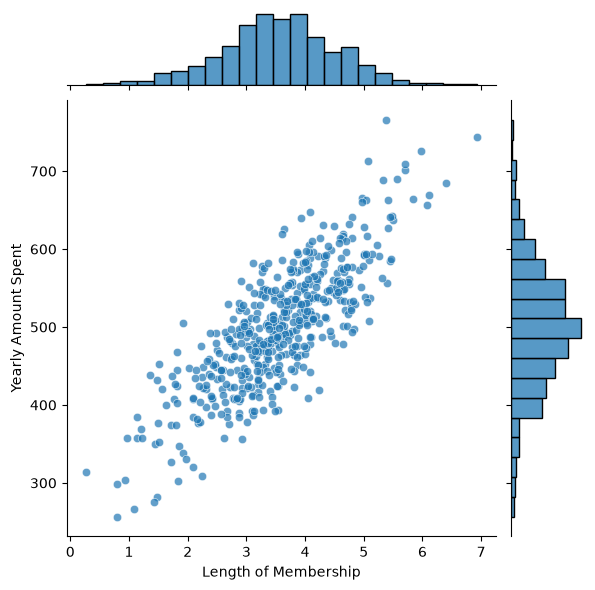

In [7]:
num_cols = ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership',]
for col in num_cols:
    sns.jointplot(x=col, y="Yearly Amount Spent", data=df, alpha=0.7)
    plt.show()

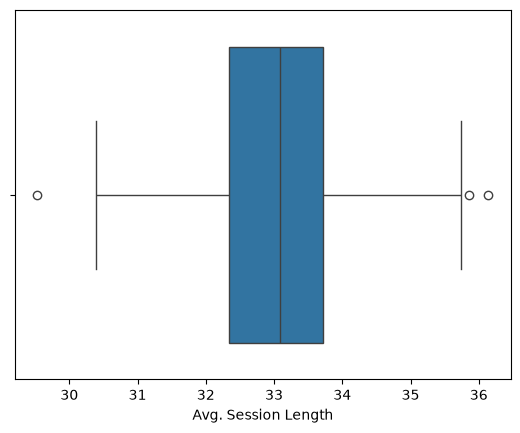

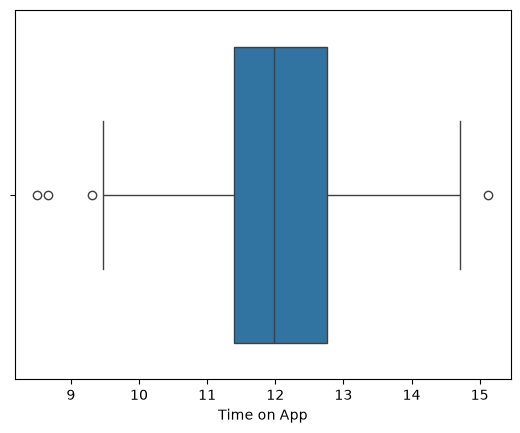

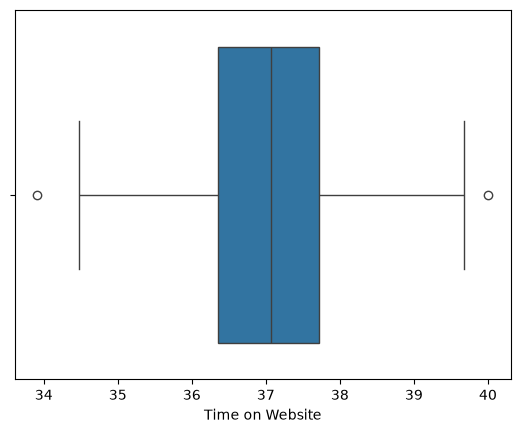

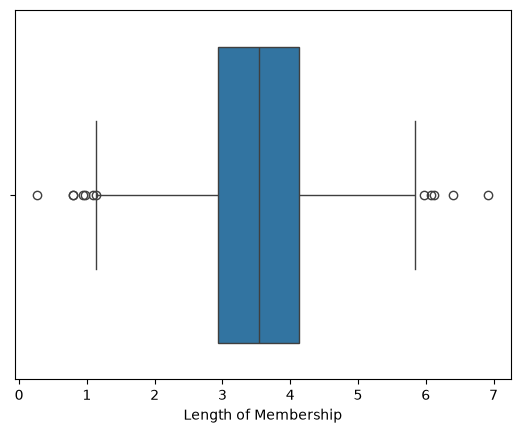

In [8]:
# Check for outlier
numericl_cols = ['Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership']
for col in numericl_cols:
    sns.boxplot(data=df, x=col)
    plt.show()

There are some outliers but due to the small size of the dataset removing them could lead to other problem hence we use them.

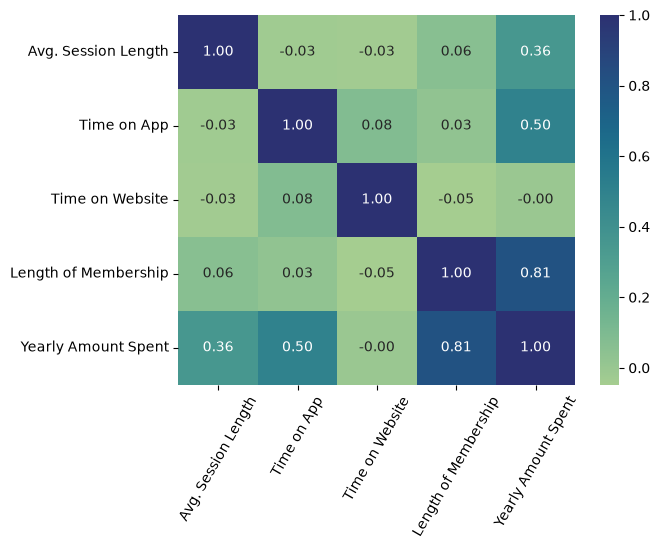

In [9]:
sns.heatmap(df.corr(), annot=True, cmap="crest", fmt=".2f")
plt.xticks(rotation=60)
plt.show()

In [10]:
# The correlation of "Time on Website" with the target columns is insignificant hence we drop it

df = df.drop(columns=["Time on Website"])

# Train Test Split

In [11]:
from sklearn.model_selection import train_test_split

X = df[['Avg. Session Length', 'Time on App', 'Length of Membership']]
y = df['Yearly Amount Spent']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# Linear Regression Model

In [13]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

In [14]:
# Fit the model
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[25.6 ,38.81,61.88]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Avg. Session Length','Time on App','Length of Membership']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1033
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [15]:
coef = pd.DataFrame(reg.coef_, X.columns, columns=["Coef"])
print(coef)

                           Coef
Avg. Session Length   25.599105
Time on App           38.811217
Length of Membership  61.882279


In [16]:
# Prediction
prediction = reg.predict(X_test)

# Model Evaluation

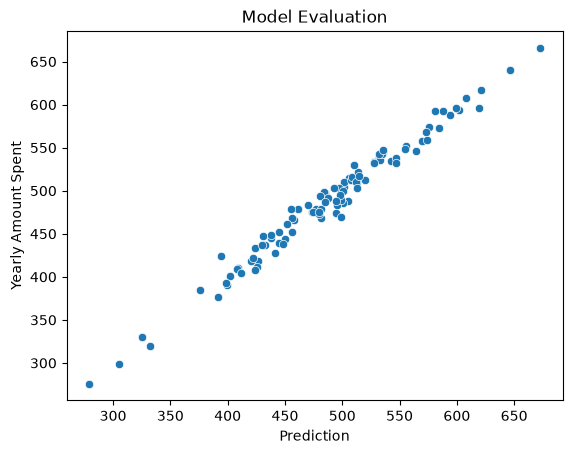

In [17]:
sns.scatterplot(x=prediction, y=y_test)
plt.xlabel("Prediction")
plt.title("Model Evaluation")
plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math as m

In [19]:
print(f"Mean Absolute Error:     {mean_absolute_error(y_test, prediction)}")
print(f"Mean Squared Error:      {mean_squared_error(y_test, prediction)}")
print(f"Root Mean Squared Error: {m.sqrt(mean_squared_error(y_test, prediction))}")

Mean Absolute Error:     8.583564848964613
Mean Squared Error:      110.32288587780576
Root Mean Squared Error: 10.503470182649435


# Residual Analysis

In [20]:
residuals = y_test - prediction

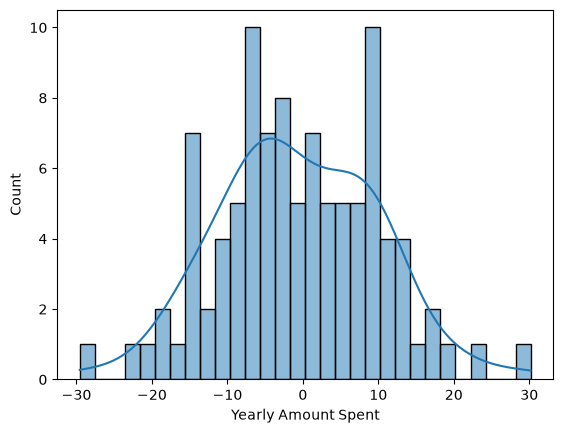

In [38]:
sns.histplot(residuals, kde=True, bins=30)
plt.show()

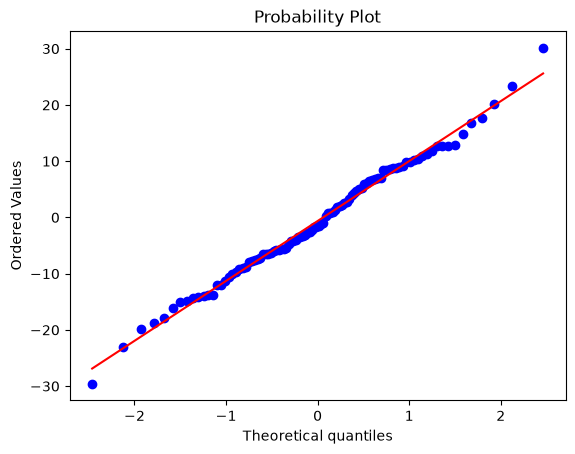

In [ ]:
# Quntile-Quntile(Q-Q) Plot

import scipy.stats as stats

stats.probplot(residuals, dist='norm', plot=plt)
plt.show()

In [ ]:
print(np.mean(residuals))

-0.6385402165746541


### **Interpretation**

The residual histogram is approximately bell-shaped, and the Q-Q plot shows that most points are close to the reference line(red line), suggesting that the residuals are approximately normally distributed. The mean residual is **-0.64**, which is close to zero, indicating litle overall bias in the model's predictions.